In [1]:
# Libraries

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os

In [2]:
df = pd.read_csv("data/customer_queries.csv")

df.head()

,query,intent,clean_query
0,I submitted my claim last week but I have not ...,claim_enquiry,i submitted my claim last week but i have not ...
1,"Good day, I submitted my claim last week but I...",claim_enquiry,good day i submitted my claim last week but i ...
2,"Hi, I submitted my claim last week but I have ...",claim_enquiry,hi i submitted my claim last week but i have n...
3,"Hello, I submitted my claim last week but I ha...",claim_enquiry,hello i submitted my claim last week but i hav...
4,"Please assist, I submitted my claim last week ...",claim_enquiry,please assist i submitted my claim last week b...


In [6]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nIntent distribution:")
print(df["intent"].value_counts())

Dataset shape: (360, 3)

Columns:
Index(['query', 'intent', 'clean_query'], dtype='object')

Missing values:
query          0
intent         0
clean_query    0
dtype: int64

Intent distribution:
intent
claim_enquiry          60
policy_update          60
benefit_question       60
complaint              60
payment_issue          60
general_information    60
Name: count, dtype: int64


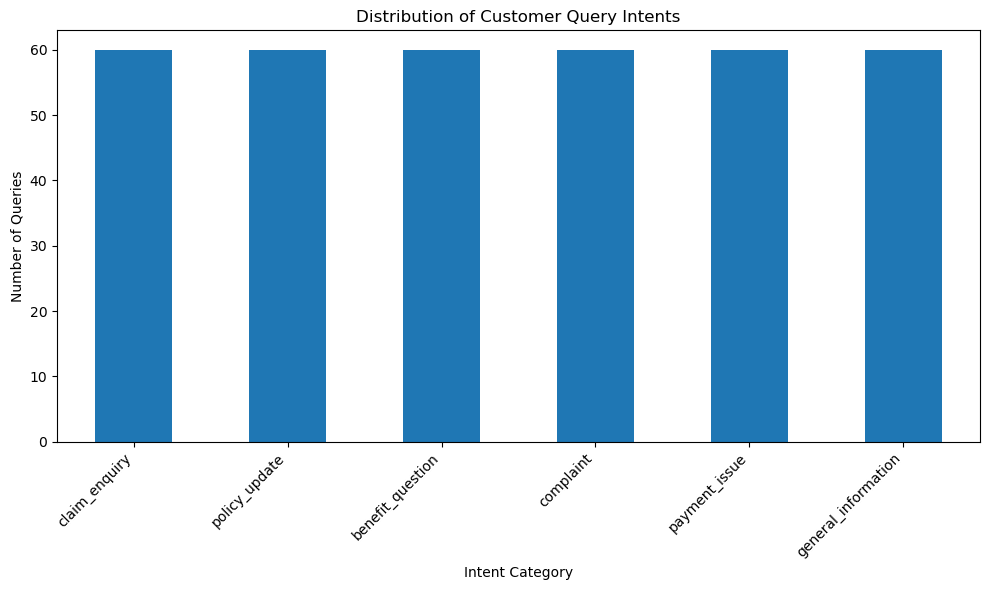

In [10]:
# Create output folder

os.makedirs("outputs/figures", exist_ok=True)

plt.figure(figsize=(10, 6))
df["intent"].value_counts().plot(kind="bar")
plt.title("Distribution of Customer Query Intents")
plt.xlabel("Intent Category")
plt.ylabel("Number of Queries")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("outputs/figures/intent_distribution.png", dpi=300)
plt.show()

In [12]:
df["query_length"] = df["clean_query"].apply(lambda x: len(str(x).split()))

df[["query", "intent", "query_length"]].head()

,query,intent,query_length
0,I submitted my claim last week but I have not ...,claim_enquiry,13
1,"Good day, I submitted my claim last week but I...",claim_enquiry,15
2,"Hi, I submitted my claim last week but I have ...",claim_enquiry,14
3,"Hello, I submitted my claim last week but I ha...",claim_enquiry,14
4,"Please assist, I submitted my claim last week ...",claim_enquiry,15


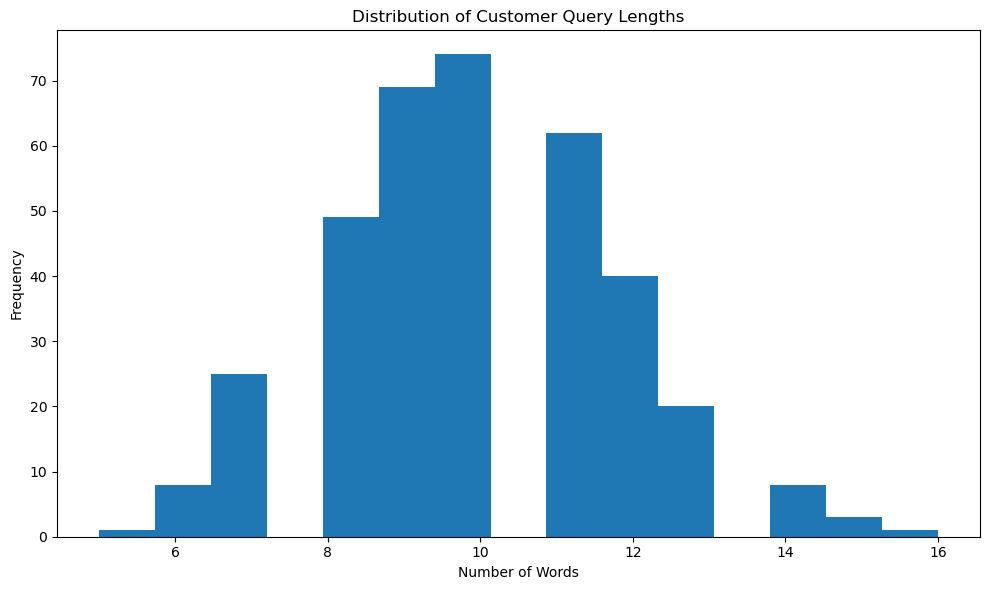

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df["query_length"], bins=15)
plt.title("Distribution of Customer Query Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("outputs/figures/intent_distribution.png", dpi=300)
plt.show()

In [16]:
avg_length = df.groupby("intent")["query_length"].mean().sort_values(ascending=False)

avg_length

intent
claim_enquiry          11.5
policy_update          10.3
payment_issue           9.9
complaint               9.8
benefit_question        9.2
general_information     8.9
Name: query_length, dtype: float64

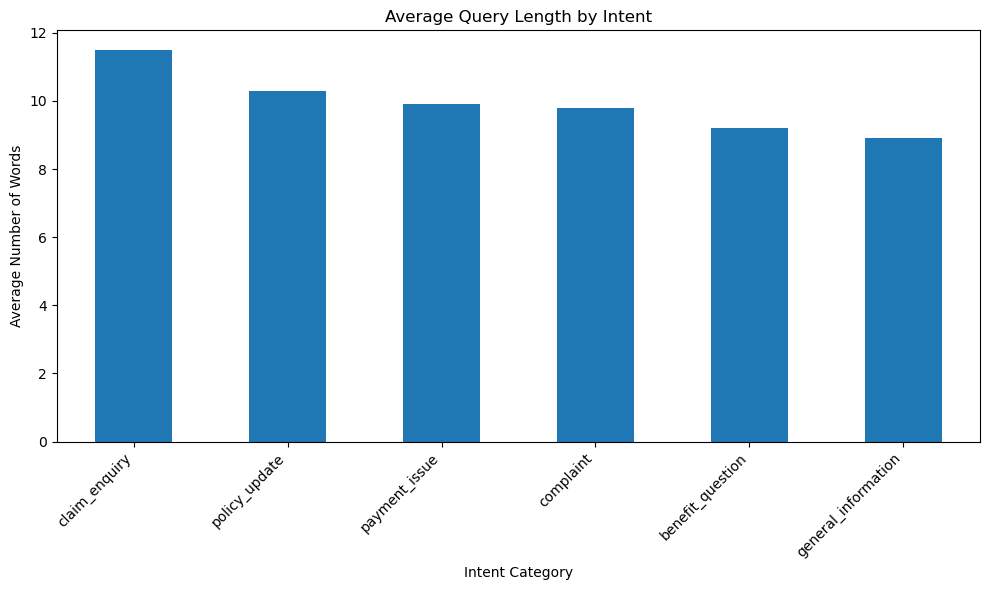

In [20]:
plt.figure(figsize=(10, 6))
avg_length.plot(kind="bar")
plt.title("Average Query Length by Intent")
plt.xlabel("Intent Category")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("outputs/figures/intent_distribution.png", dpi=300)
plt.show()

In [22]:
all_words = " ".join(df["clean_query"]).split()

word_counts = Counter(all_words)

common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "frequency"]
)

common_words

,word,frequency
0,i,282
1,my,252
2,please,114
3,need,96
4,to,84
5,help,78
6,day,72
7,assist,72
8,claim,66
9,the,66


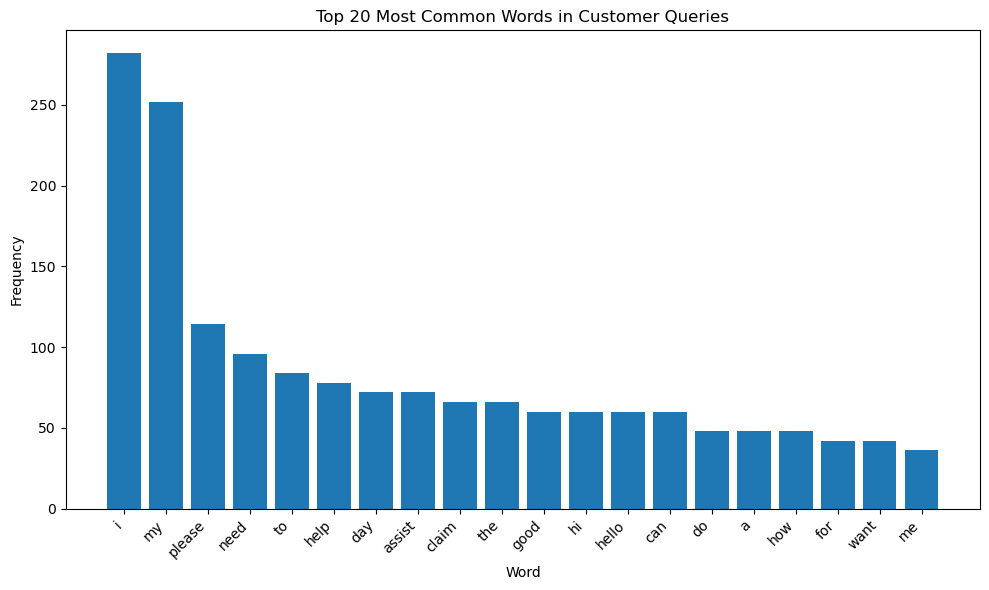

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(common_words["word"], common_words["frequency"])
plt.title("Top 20 Most Common Words in Customer Queries")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("outputs/figures/intent_distribution.png", dpi=300)
plt.show()

In [26]:
summary_table = df.groupby("intent").agg(
    number_of_queries=("query", "count"),
    average_query_length=("query_length", "mean"),
    minimum_query_length=("query_length", "min"),
    maximum_query_length=("query_length", "max")
).reset_index()

summary_table

,intent,number_of_queries,average_query_length,minimum_query_length,maximum_query_length
0,benefit_question,60,9.2,6,13
1,claim_enquiry,60,11.5,8,16
2,complaint,60,9.8,6,15
3,general_information,60,8.9,5,13
4,payment_issue,60,9.9,7,14
5,policy_update,60,10.3,7,14


In [30]:
summary_table.to_csv("data/eda_summary_by_intent.csv", index=False)

print("EDA summary table saved successfully.")

EDA summary table saved successfully.
